# Exercise 4 -  NumPy Array Operations


In [1]:
import numpy as np

# Task 1: Create a 5x5 matrix where border elements are 1 and interior is 0
matrix = np.ones((5, 5))
matrix[1:4, 1:4] = 0
print("Task 1 - Border Matrix:")
print(matrix)

# Task 2: Normalize a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)
print("\nTask 2 - Normalized Data:")
print(f"Mean (should be ~0): {normalized.mean(axis=0).round(10)}")
print(f"Std (should be ~1): {normalized.std(axis=0).round(10)}")

# Task 3: Linear regression using normal equation
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Normal equation: theta = (X^T X)^(-1) X^T y
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("\nTask 3 - Linear Regression:")
print(f"True theta:      {true_theta}")
print(f"Estimated theta: {theta_hat.round(4)}")

Task 1 - Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]

Task 2 - Normalized Data:
Mean (should be ~0): [-0.  0. -0.]
Std (should be ~1): [1. 1. 1.]

Task 3 - Linear Regression:
True theta:      [ 2.5 -1.2  3.7]
Estimated theta: [ 2.5172 -1.1978  3.724 ]


Exercise 5 - Pandas Data Analysis

In [2]:
import pandas as pd
import numpy as np

# Create sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introduce some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

# Task 1: Data Cleaning and Exploration
print("Task 1: Data Cleaning ")
print(df.info())
print("\nMissing values:")
print(df.isnull().sum())

# Fill missing exam_score with mean score for student's major
df['exam_score'] = df.groupby('major')['exam_score'].transform(lambda x: x.fillna(x.mean()))

# Fill missing hours_studied with median for student's year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(lambda x: x.fillna(x.median()))

print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Task 2: Analysis
print("\nTask 2: Analysis")
avg_by_major = df.groupby('major')['exam_score'].mean()
print("Average exam score by major:")
print(avg_by_major)

print(f"\nMajor with highest average: {avg_by_major.idxmax()}")

correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation between hours studied and exam score: {correlation:.4f}")

# Performance categories
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)
print("\nPerformance distribution:")
print(df['performance'].value_counts())

# Task 3: Advanced Analysis
print("\n Task 3: Advanced Analysis ")
group_analysis = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print("Group analysis:")
print(group_analysis)

# Top 5 students
top5 = df.nlargest(5, 'exam_score')[['student_id', 'major', 'year', 'exam_score']]
print("\nTop 5 students:")
print(top5)

# Pivot table
pivot = pd.pivot_table(df, values='exam_score', index='major', columns='year', aggfunc='mean').round(2)
print("\nPivot table - Average exam score by major and year:")
print(pivot)

Task 1: Data Cleaning 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    object 
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int64  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 9.5+ KB
None

Missing values:
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

Missing values after cleaning:
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            

# Exercise 6 - Data Visualization

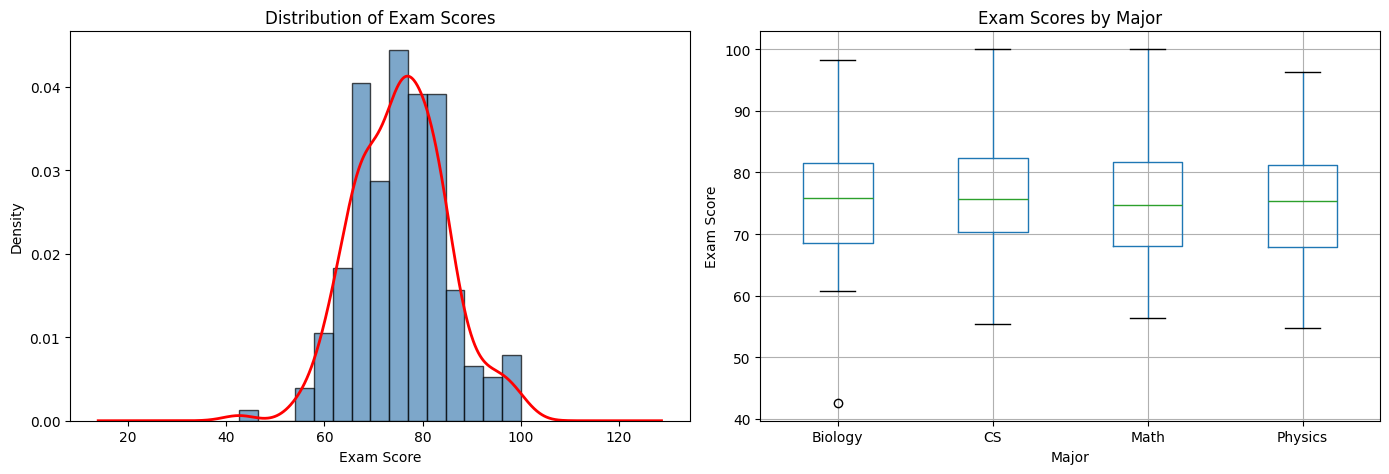

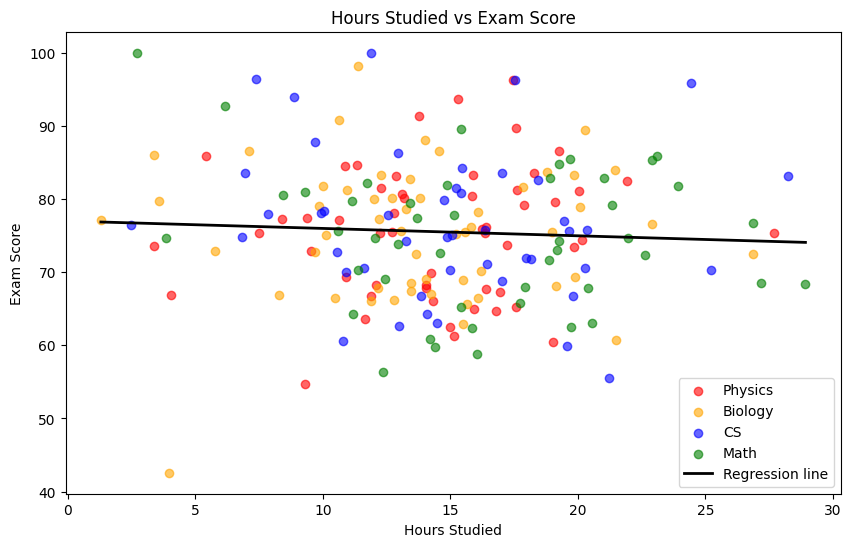

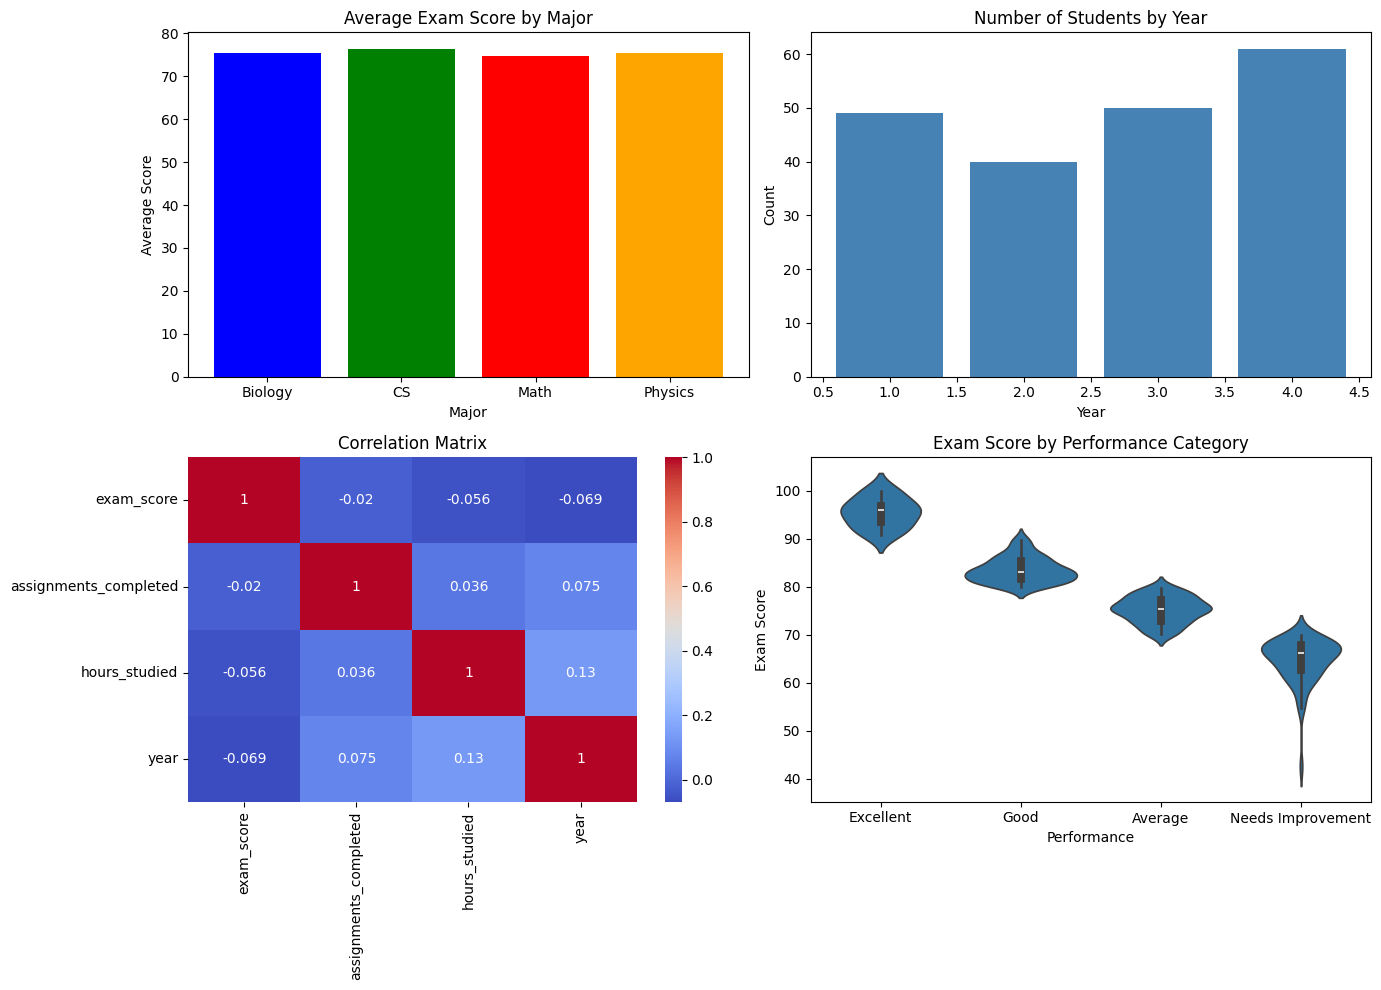

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Task 1: Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Histogram with KDE overlay
axes[0].hist(df['exam_score'], bins=15, edgecolor='black', color='steelblue', alpha=0.7, density=True)
df['exam_score'].plot.kde(ax=axes[0], color='red', linewidth=2)
axes[0].set_title('Distribution of Exam Scores')
axes[0].set_xlabel('Exam Score')
axes[0].set_ylabel('Density')

# Right: Box plot by major
df.boxplot(column='exam_score', by='major', ax=axes[1])
axes[1].set_title('Exam Scores by Major')
axes[1].set_xlabel('Major')
axes[1].set_ylabel('Exam Score')
plt.suptitle('')
plt.tight_layout()
plt.show()

# Task 2: Scatter plot
plt.figure(figsize=(10, 6))
colors = {'CS': 'blue', 'Math': 'green', 'Physics': 'red', 'Biology': 'orange'}
for major in df['major'].unique():
    subset = df[df['major'] == major]
    plt.scatter(subset['hours_studied'], subset['exam_score'],
                label=major, alpha=0.6, color=colors[major])

# Regression line
m, b = np.polyfit(df['hours_studied'], df['exam_score'], 1)
x_line = np.linspace(df['hours_studied'].min(), df['hours_studied'].max(), 100)
plt.plot(x_line, m * x_line + b, color='black', linewidth=2, label='Regression line')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Hours Studied vs Exam Score')
plt.legend()
plt.show()

# Task 3: 2x2 Dashboard
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()
axes[0, 0].bar(avg_scores.index, avg_scores.values, color=['blue', 'green', 'red', 'orange'])
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')

# 2. Count plot: Number of students by year
year_counts = df['year'].value_counts().sort_index()
axes[0, 1].bar(year_counts.index, year_counts.values, color='steelblue')
axes[0, 1].set_title('Number of Students by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')

# 3. Heatmap: Correlation matrix
numeric_cols = df[['exam_score', 'assignments_completed', 'hours_studied', 'year']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

# 4. Violin plot: Exam score by performance category
order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
sns.violinplot(data=df, x='performance', y='exam_score', order=order, ax=axes[1, 1])
axes[1, 1].set_title('Exam Score by Performance Category')
axes[1, 1].set_xlabel('Performance')
axes[1, 1].set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

#Integration Challenge

=== Age Group Analysis ===
           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 81    50634.02   718.37   58188.06
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

=== Top 10% Customers (CLV >= 1222.94) ===
Number of top customers: 50
         age    income  purchase_frequency      CLV
count  50.00     50.00               50.00    50.00
mean   47.90  47864.94                7.68  1398.89
std    13.35  17862.38                1.49   110.59
min    20.00  15000.00                5.00  1234.07
25%    40.00  36404.71                7.00  1318.33
50%    46.00  48777.96                7.00  1370.14
75%    60.00  58026.96                8.00  1493.15
max    69.00  86629.18               12.00  1645.71


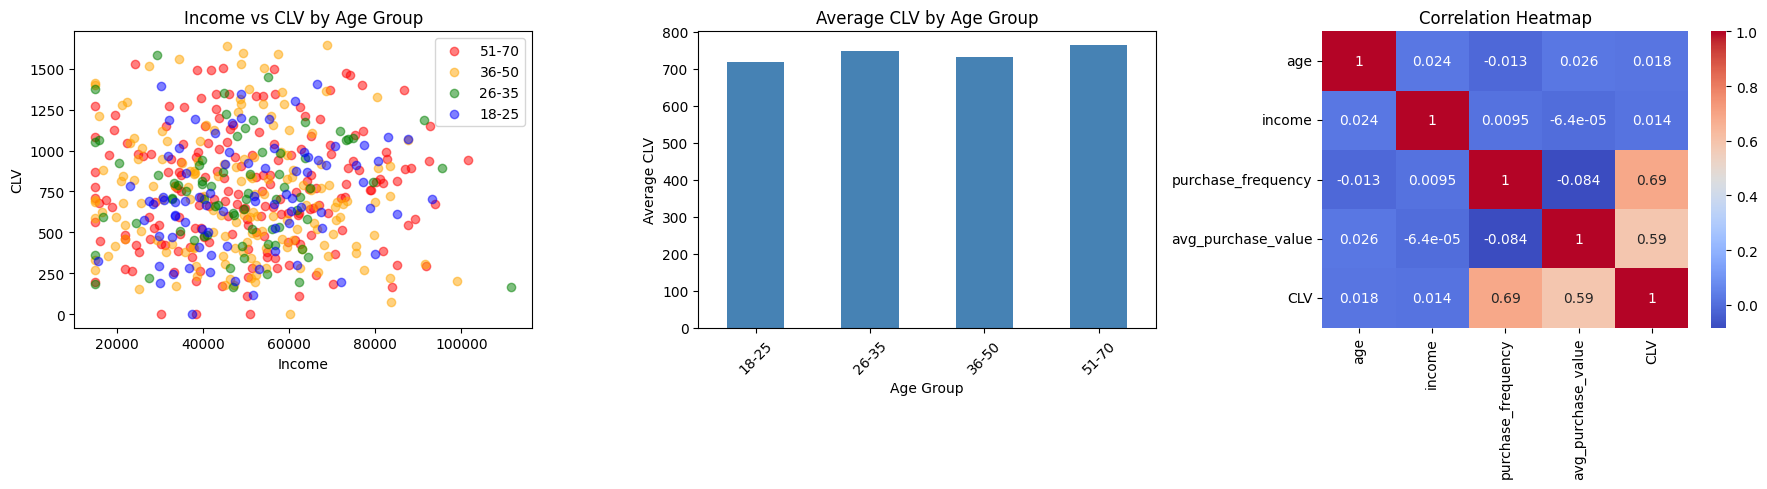

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generate customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculate CLV
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk'])

# Create age groups
customers['age_group'] = pd.cut(customers['age'],
                                bins=[17, 25, 35, 50, 70],
                                labels=['18-25', '26-35', '36-50', '51-70'])

# Analysis by age group
age_analysis = customers.groupby('age_group', observed=True).agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)

print("=== Age Group Analysis ===")
print(age_analysis)

# Top 10% customers by CLV
top10_threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= top10_threshold]
print(f"\n=== Top 10% Customers (CLV >= {top10_threshold:.2f}) ===")
print(f"Number of top customers: {len(top_customers)}")
print(top_customers[['age', 'income', 'purchase_frequency', 'CLV']].describe().round(2))

# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter plot: income vs CLV colored by age group
colors = {'18-25': 'blue', '26-35': 'green', '36-50': 'orange', '51-70': 'red'}
for group in customers['age_group'].unique():
    subset = customers[customers['age_group'] == group]
    axes[0].scatter(subset['income'], subset['CLV'],
                   label=group, alpha=0.5, color=colors[str(group)])
axes[0].set_title('Income vs CLV by Age Group')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('CLV')
axes[0].legend()

#  Bar chart: average CLV by age group
age_analysis['avg_CLV'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Average CLV by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV')
axes[1].tick_params(axis='x', rotation=45)

# Correlation heatmap
numeric_data = customers[['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']]
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', ax=axes[2])
axes[2].set_title('Correlation Heatmap')

plt.tight_layout()
plt.show()